In [9]:
import os
import numpy as np
import random
from PIL import Image, ImageEnhance
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from sklearn.utils import shuffle

      

Loss Function

All five models in this study are trained using Sparse Categorical
Crossentropy as the loss function:

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

Why this loss function is used:

This is a multi-class classification problem with four mutually
exclusive classes (glioma, meningioma, pituitary, notumor) — each MRI
image belongs to exactly one class. Categorical Crossentropy is the
standard loss function for this type of problem because it directly
penalizes the model based on how far the predicted probability
distribution is from the true class.

The "sparse" variant is used specifically because the class labels
in this project are encoded as integers (0, 1, 2, 3) rather than
one-hot encoded vectors (e.g., [0, 1, 0, 0]). Sparse Categorical
Crossentropy accepts integer labels directly, which:


Avoids the memory overhead of one-hot encoding the labels
Matches the output of encode_label(), which returns integer-encoded
labels via unique_labels.index(label)


Mathematically, for a true class y and predicted probability
distribution ŷ (the softmax output), the loss for a single sample is:

L = -log(ŷ_y)

where ŷ_y is the predicted probability assigned to the correct class.
This formulation strongly penalizes confident wrong predictions (e.g.,
predicting 5% probability for the correct class results in a much
higher loss than predicting 40%), which encourages the network to
produce well-calibrated, confident, and correct probability estimates
— a desirable property for a medical diagnostic tool where confidence
calibration matters.

The final layer of every model uses a Softmax activation with 4
output units (one per class), which converts raw network outputs into
a valid probability distribution that sums to 1 — the required input
format for Categorical Crossentropy.

In [10]:
from sklearn.model_selection import train_test_split

train_dir = 'D:/Study/A_UniVR Class/ML & DP/DL/Brain Tumor Detection Project (Deep Learning)/MRI Images/Training'
test_dir = 'D:/Study/A_UniVR Class/ML & DP/DL/Brain Tumor Detection Project (Deep Learning)/MRI Images/Testing'

# Load and shuffle the train data
train_paths = []
train_labels = []
for label in os.listdir(train_dir):
    for image in os.listdir(os.path.join(train_dir, label)):
        train_paths.append(os.path.join(train_dir, label, image))
        train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

# Load and shuffle the test data
test_paths = []
test_labels = []
for label in os.listdir(test_dir):
    for image in os.listdir(os.path.join(test_dir, label)):
        test_paths.append(os.path.join(test_dir, label, image))
        test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)

# ── Split training data into Train + Validation ─────────────────────────────
train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_paths, train_labels,
    test_size=0.15,
    random_state=42,
    stratify=train_labels
)

print(f'Training   : {len(train_paths)} images')
print(f'Validation : {len(val_paths)} images')
print(f'Testing    : {len(test_paths)} images')

Training   : 4855 images
Validation : 857 images
Testing    : 1311 images


In [11]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense, Conv2D, MaxPooling2D, LSTM, Reshape, concatenate
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2
from tensorflow.keras.optimizers import Adam

In [12]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.utils import shuffle
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

from PIL import Image, ImageEnhance
import numpy as np
import random

In [21]:
def val_datagen(paths, labels, batch_size, image_size=128):
    while True:
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i+batch_size]
            batch_labels = labels[i:i+batch_size]
            batch_images = []
            for p in batch_paths:
                img = load_img(p, target_size=(image_size, image_size))
                img = img_to_array(img) / 255.0
                batch_images.append(img)
            batch_labels = encode_label(batch_labels) 
            yield np.array(batch_images), np.array(batch_labels)

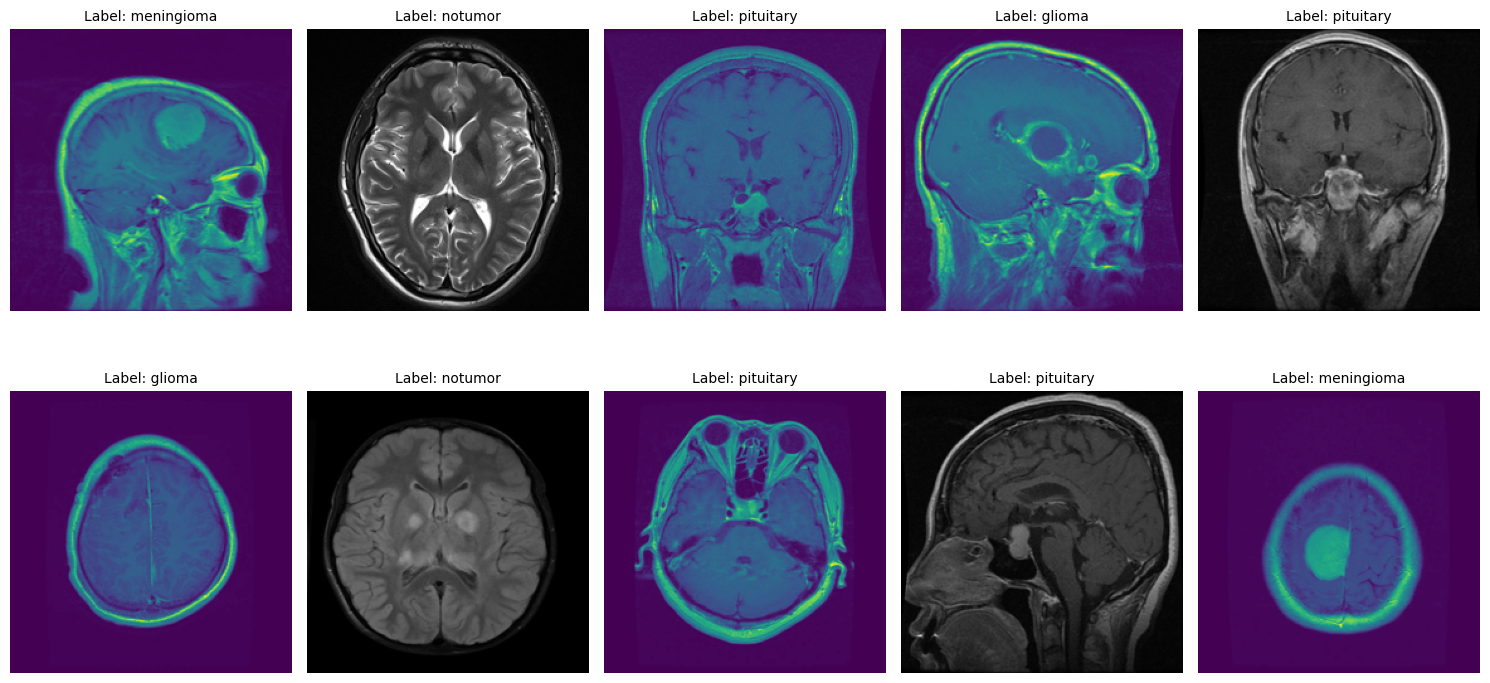

In [22]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import os

# Select random indices for 10 images
random_indices = random.sample(range(len(train_paths)), 10)

# Create a figure to display images in 2 rows
fig, axes = plt.subplots(2, 5, figsize=(15, 8))
axes = axes.ravel()

for i, idx in enumerate(random_indices):
    # Load image
    img_path = train_paths[idx]
    img = Image.open(img_path)
    img = img.resize((224, 224))

    # Display image
    axes[i].imshow(img)
    axes[i].axis('off')
    # Display class label in the second row
    axes[i].set_title(f"Label: {train_labels[idx]}", fontsize=10)

plt.tight_layout()
plt.show()

In [23]:
# Image Augmentation function
def augment_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))
    image = np.array(image) / 255.0
    return image

# Load images and apply augmentation
def open_images(paths):
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        image = augment_image(image)
        images.append(image)
    return np.array(images)

# Encoding labels (convert label names to integers)
def encode_label(labels):
    unique_labels = os.listdir(train_dir)
    encoded = [unique_labels.index(label) for label in labels]
    return np.array(encoded)

# Data generator for batching
def datagen(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            batch_images = open_images(batch_paths)
            batch_labels = labels[i:i + batch_size]
            batch_labels = encode_label(batch_labels)
            yield batch_images, batch_labels

In [24]:
import tensorflow as tf
tf.debugging.disable_traceback_filtering()

In [25]:
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU memory growth enabled for {len(gpus)} GPU(s)")
    except RuntimeError as e:
        print(e)

Physical devices cannot be modified after being initialized


**MODEL : VGG16**

In [26]:
# Model architecture
IMAGE_SIZE = 128
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

for layer in base_model.layers:
    layer.trainable = False

base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))
model.add(base_model)
model.add(Flatten())
model.add(Dropout(0.3))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(len(os.listdir(train_dir)), activation='softmax'))

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

# Parameters
batch_size = 20
steps = int(len(train_paths) / batch_size)
val_steps = int(len(val_paths) / batch_size)     
epochs = 10

# Train the model (with validation)
history_vgg16 = model.fit(                        
    datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
    validation_data=val_datagen(val_paths, val_labels, batch_size=batch_size, image_size=IMAGE_SIZE),  
    validation_steps=val_steps,                    
    epochs=epochs,
    steps_per_epoch=steps
)

Epoch 1/10
242/242 [==============================] - 14s 52ms/step - loss: 0.4761 - sparse_categorical_accuracy: 0.8149 - val_loss: 0.2671 - val_sparse_categorical_accuracy: 0.8940
Epoch 2/10
242/242 [==============================] - 13s 50ms/step - loss: 0.2518 - sparse_categorical_accuracy: 0.9071 - val_loss: 0.1992 - val_sparse_categorical_accuracy: 0.9214
Epoch 3/10
242/242 [==============================] - 12s 49ms/step - loss: 0.1699 - sparse_categorical_accuracy: 0.9311 - val_loss: 0.1769 - val_sparse_categorical_accuracy: 0.9369
Epoch 4/10
242/242 [==============================] - 12s 49ms/step - loss: 0.1300 - sparse_categorical_accuracy: 0.9518 - val_loss: 0.2137 - val_sparse_categorical_accuracy: 0.9286
Epoch 5/10
242/242 [==============================] - 12s 49ms/step - loss: 0.0945 - sparse_categorical_accuracy: 0.9648 - val_loss: 0.1815 - val_sparse_categorical_accuracy: 0.9405
Epoch 6/10
242/242 [==============================] - 12s 51ms/step - loss: 0.0716 - spars

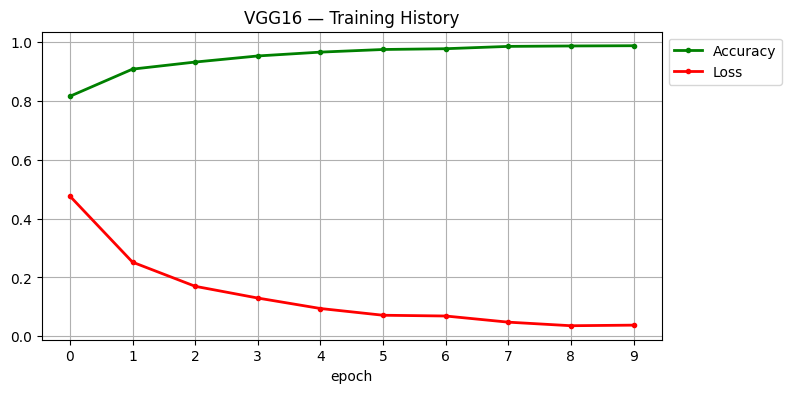

In [28]:
# ── Training History Plot (VGG16) ────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.grid(True)
plt.plot(history_vgg16.history['sparse_categorical_accuracy'], '.g-', linewidth=2)
plt.plot(history_vgg16.history['loss'], '.r-', linewidth=2)
plt.title('VGG16 — Training History')
plt.xlabel('epoch')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1, 1))
plt.savefig('training_history_vgg16.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
# ── Validation/Test data loader (NO augmentation) ────────────────────────────
def open_images_no_aug(paths):
    """Loads and normalizes images WITHOUT augmentation — for validation/test only."""
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        image = img_to_array(image) / 255.0
        images.append(image)
    return np.array(images)

# ── Validation data generator (for use in model.fit) ─────────────────────────
def val_datagen(paths, labels, batch_size, image_size=128):
    while True:
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i+batch_size]
            batch_labels = labels[i:i+batch_size]
            batch_images = open_images_no_aug(batch_paths)
            batch_labels = encode_label(batch_labels)
            yield np.array(batch_images), np.array(batch_labels)

In [32]:



# ── Evaluation (VGG16) ────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
from sklearn.preprocessing import label_binarize
import numpy as np

CLASS_NAMES = os.listdir(train_dir)   # dynamic — matches folder order used in encode_label()

# 1. Prediction on test data
test_images = open_images_no_aug(test_paths)     # ← FIXED: no augmentation on test data
test_labels_encoded = encode_label(test_labels)
test_predictions = model.predict(test_images)

# 2. Classification Report
print("=== VGG16 — Classification Report ===")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1),
                             target_names=CLASS_NAMES))





41/41 [==============================] - 1s 33ms/step
=== VGG16 — Classification Report ===
              precision    recall  f1-score   support

      glioma       0.96      0.94      0.95       300
  meningioma       0.94      0.93      0.93       306
     notumor       0.98      1.00      0.99       405
   pituitary       0.99      0.99      0.99       300

    accuracy                           0.97      1311
   macro avg       0.97      0.96      0.97      1311
weighted avg       0.97      0.97      0.97      1311



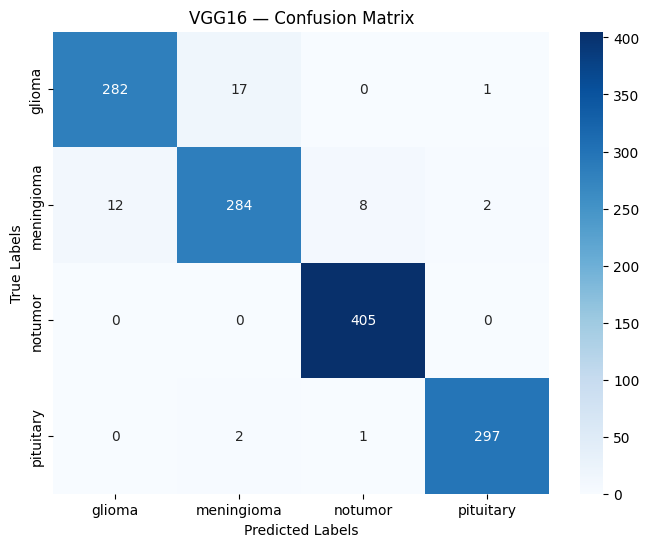

In [34]:
# 3. Confusion Matrix
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("VGG16 — Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.savefig('confusion_matrix_vgg16.png', dpi=150, bbox_inches='tight')
plt.show()

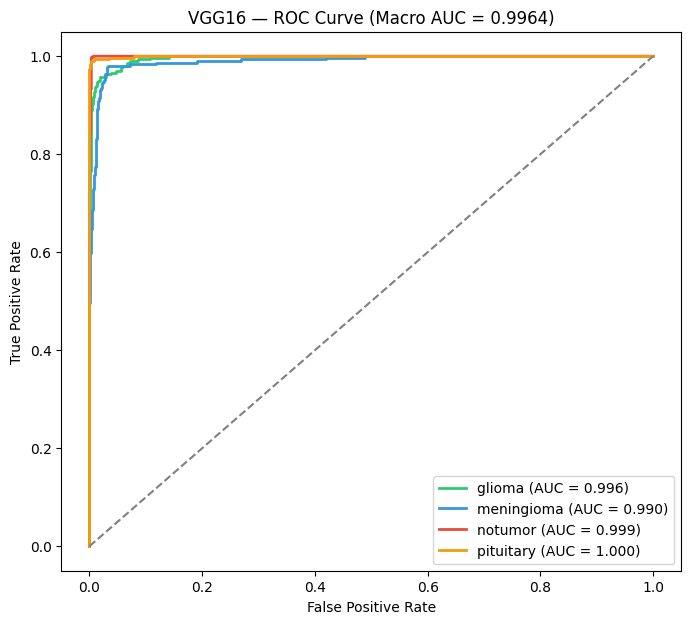


VGG16 — Macro Average AUC: 0.9964


In [35]:
# 4. ROC Curve and AUC
n_classes = len(CLASS_NAMES)
test_labels_bin = label_binarize(test_labels_encoded, classes=np.arange(n_classes))

fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_predictions[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

macro_auc_vgg16 = np.mean(list(roc_auc.values()))

plt.figure(figsize=(8, 7))
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, linewidth=2,
             label=f'{CLASS_NAMES[i]} (AUC = {roc_auc[i]:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title(f"VGG16 — ROC Curve (Macro AUC = {macro_auc_vgg16:.4f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.savefig('roc_auc_vgg16.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nVGG16 — Macro Average AUC: {macro_auc_vgg16:.4f}")

In [37]:
# ── Qualitative Example (VGG16) ───────────────────────────────────────────────
from tensorflow.keras.preprocessing.image import load_img, img_to_array

CLASS_LABELS = os.listdir(train_dir)   # FIXED: dynamic, matches actual folder order

def detect_and_display(img_path, model, image_size=128):
    try:
        img = load_img(img_path, target_size=(image_size, image_size))
        img_array = img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions, axis=1)[0]
        confidence_score = np.max(predictions, axis=1)[0]

        predicted_label = CLASS_LABELS[predicted_class_index]
        result = "No Tumor" if predicted_label == 'notumor' else f"Tumor: {predicted_label}"

        plt.imshow(load_img(img_path))
        plt.axis('off')
        plt.title(f"{result} (Confidence: {confidence_score * 100:.2f}%)")
        plt.show()

    except Exception as e:
        print("Error processing the image:", str(e))




1/1 [==============================] - 0s 29ms/step


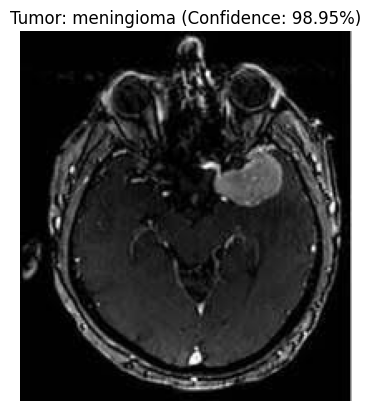

In [39]:
# Example usage
image_path = 'D:/Study/A_UniVR Class/ML & DP/DL/Brain Tumor Detection Project (Deep Learning)/MRI Images/Testing/meningioma/Te-me_0011.jpg'
detect_and_display(image_path, model)

In [40]:


from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, UpSampling2D,
    Flatten, Dense, Dropout, Concatenate,
    LSTM, Reshape
)
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report


**Model RestNet50**

In [41]:
IMAGE_SIZE = 128
base_model = ResNet50(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

for layer in base_model.layers:
    layer.trainable = False

base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

model_resnet50 = Sequential()
model_resnet50.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))
model_resnet50.add(base_model)
model_resnet50.add(Flatten())
model_resnet50.add(Dropout(0.3))
model_resnet50.add(Dense(128, activation='relu'))
model_resnet50.add(Dropout(0.2))
model_resnet50.add(Dense(len(os.listdir(train_dir)), activation='softmax'))

model_resnet50.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

# Parameters
batch_size = 20
steps = int(len(train_paths) / batch_size)
val_steps = int(len(val_paths) / batch_size)    
epochs = 10

# Train the model (FIXED: model_resnet50.fit, not model.fit)
history_resnet50 = model_resnet50.fit(                                          
    datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
    validation_data=val_datagen(val_paths, val_labels, batch_size=batch_size, image_size=IMAGE_SIZE), 
    validation_steps=val_steps,                                                  
    epochs=epochs,
    steps_per_epoch=steps
)

94765736/94765736 [==============================] - 14s 0us/step
Epoch 1/10
242/242 [==============================] - 16s 56ms/step - loss: 0.8269 - sparse_categorical_accuracy: 0.6508 - val_loss: 1.0549 - val_sparse_categorical_accuracy: 0.4857
Epoch 2/10
242/242 [==============================] - 14s 58ms/step - loss: 0.6096 - sparse_categorical_accuracy: 0.7477 - val_loss: 0.5226 - val_sparse_categorical_accuracy: 0.7893
Epoch 3/10
242/242 [==============================] - 15s 62ms/step - loss: 0.5516 - sparse_categorical_accuracy: 0.7727 - val_loss: 0.4958 - val_sparse_categorical_accuracy: 0.7929
Epoch 4/10
242/242 [==============================] - 15s 61ms/step - loss: 0.5105 - sparse_categorical_accuracy: 0.7899 - val_loss: 0.3980 - val_sparse_categorical_accuracy: 0.8500
Epoch 5/10
242/242 [==============================] - 14s 58ms/step - loss: 0.4677 - sparse_categorical_accuracy: 0.8052 - val_loss: 0.4895 - val_sparse_categorical_accuracy: 0.8119
Epoch 6/10
242/242 [====

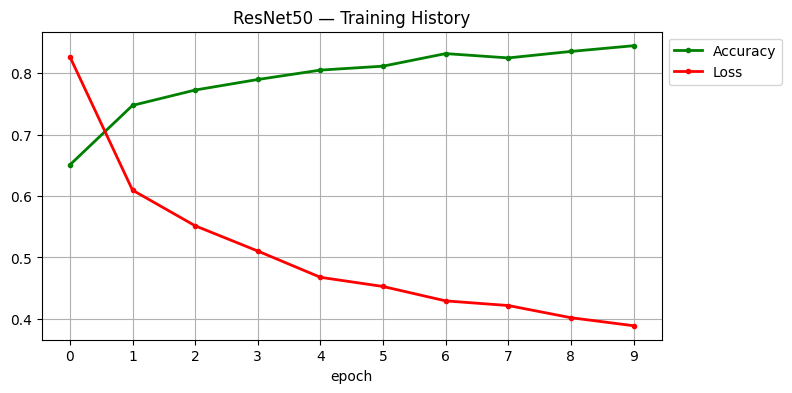

In [42]:
# ── Training History Plot (ResNet50) ─────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.grid(True)
plt.plot(history_resnet50.history['sparse_categorical_accuracy'], '.g-', linewidth=2)
plt.plot(history_resnet50.history['loss'], '.r-', linewidth=2)
plt.title('ResNet50 — Training History')
plt.xlabel('epoch')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1, 1))
plt.savefig('training_history_resnet50.png', dpi=150, bbox_inches='tight')
plt.show()

In [43]:
# ── Evaluation (ResNet50) ─────────────────────────────────────────────────────
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
from sklearn.preprocessing import label_binarize
import numpy as np

CLASS_NAMES = os.listdir(train_dir)

# 1. Prediction on test data
test_images = open_images_no_aug(test_paths)        # ← FIXED: no augmentation
test_labels_encoded = encode_label(test_labels)
test_predictions = model_resnet50.predict(test_images)   # ← FIXED: model_resnet50

# 2. Classification Report
print("=== ResNet50 — Classification Report ===")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1),
                             target_names=CLASS_NAMES))

41/41 [==============================] - 2s 23ms/step
=== ResNet50 — Classification Report ===
              precision    recall  f1-score   support

      glioma       1.00      0.20      0.34       300
  meningioma       0.52      0.67      0.59       306
     notumor       0.86      0.98      0.92       405
   pituitary       0.74      0.99      0.85       300

    accuracy                           0.73      1311
   macro avg       0.78      0.71      0.67      1311
weighted avg       0.79      0.73      0.69      1311



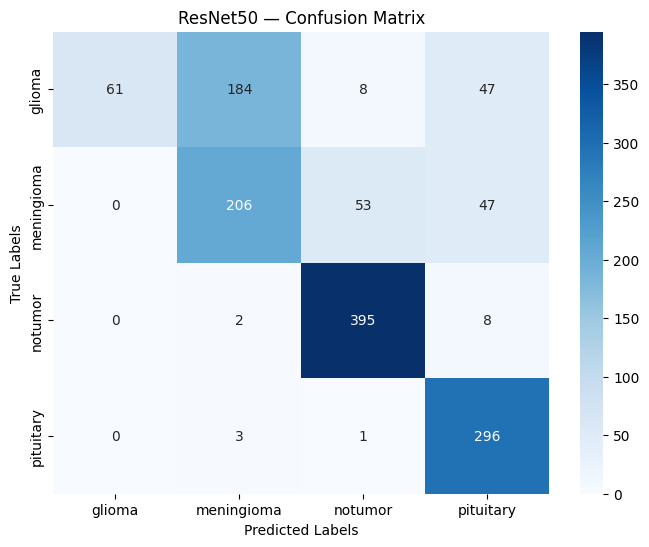

In [44]:
# 3. Confusion Matrix
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("ResNet50 — Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.savefig('confusion_matrix_resnet50.png', dpi=150, bbox_inches='tight')
plt.show()

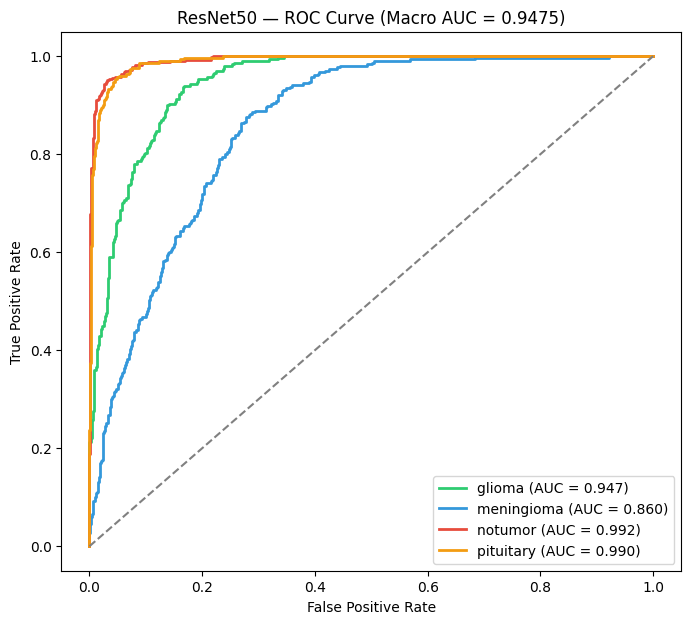


ResNet50 — Macro Average AUC: 0.9475


In [45]:
# 4. ROC Curve and AUC
n_classes = len(CLASS_NAMES)
test_labels_bin = label_binarize(test_labels_encoded, classes=np.arange(n_classes))

fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_predictions[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

macro_auc_resnet50 = np.mean(list(roc_auc.values()))

plt.figure(figsize=(8, 7))
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, linewidth=2,
             label=f'{CLASS_NAMES[i]} (AUC = {roc_auc[i]:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title(f"ResNet50 — ROC Curve (Macro AUC = {macro_auc_resnet50:.4f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.savefig('roc_auc_resnet50.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nResNet50 — Macro Average AUC: {macro_auc_resnet50:.4f}")

1/1 [==============================] - 0s 27ms/step


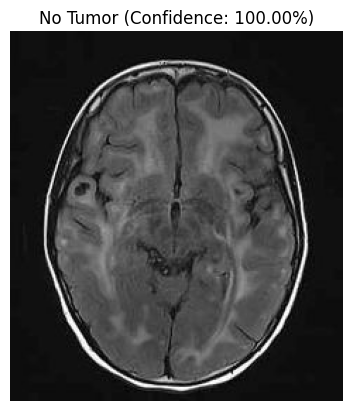

In [47]:
# Example usage
image_path = 'D:/Study/A_UniVR Class/ML & DP/DL/Brain Tumor Detection Project (Deep Learning)/MRI Images/Testing/notumor/Te-no_0019.jpg'
detect_and_display(image_path, model)

**MobileNetV2**

In [48]:
IMAGE_SIZE = 128
base_model = MobileNetV2(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

for layer in base_model.layers:
    layer.trainable = False

base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

# Build the final model (FIXED: unique variable name)
model_mobilenet = Sequential()
model_mobilenet.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))
model_mobilenet.add(base_model)
model_mobilenet.add(Flatten())
model_mobilenet.add(Dropout(0.3))
model_mobilenet.add(Dense(128, activation='relu'))
model_mobilenet.add(Dropout(0.2))
model_mobilenet.add(Dense(len(os.listdir(train_dir)), activation='softmax'))

# Compile the model
model_mobilenet.compile(optimizer=Adam(learning_rate=0.0001),
                         loss='sparse_categorical_crossentropy',
                         metrics=['sparse_categorical_accuracy'])

# Parameters
batch_size = 20
steps = int(len(train_paths) / batch_size)
val_steps = int(len(val_paths) / batch_size)    
epochs = 10

# Train the model (FIXED: model_mobilenet.fit, with validation)
history_mobilenet = model_mobilenet.fit(
    datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
    validation_data=val_datagen(val_paths, val_labels, batch_size=batch_size, image_size=IMAGE_SIZE),
    validation_steps=val_steps,
    epochs=epochs,
    steps_per_epoch=steps
)

9406464/9406464 [==============================] - 2s 0us/step
Epoch 1/10
242/242 [==============================] - 18s 65ms/step - loss: 0.4663 - sparse_categorical_accuracy: 0.8409 - val_loss: 0.3050 - val_sparse_categorical_accuracy: 0.9012
Epoch 2/10
242/242 [==============================] - 13s 55ms/step - loss: 0.1588 - sparse_categorical_accuracy: 0.9411 - val_loss: 0.2516 - val_sparse_categorical_accuracy: 0.8940
Epoch 3/10
242/242 [==============================] - 14s 58ms/step - loss: 0.0816 - sparse_categorical_accuracy: 0.9704 - val_loss: 0.1835 - val_sparse_categorical_accuracy: 0.9381
Epoch 4/10
242/242 [==============================] - 13s 54ms/step - loss: 0.0612 - sparse_categorical_accuracy: 0.9783 - val_loss: 0.1353 - val_sparse_categorical_accuracy: 0.9524
Epoch 5/10
242/242 [==============================] - 14s 59ms/step - loss: 0.0335 - sparse_categorical_accuracy: 0.9884 - val_loss: 0.1668 - val_sparse_categorical_accuracy: 0.9488
Epoch 6/10
242/242 [=======

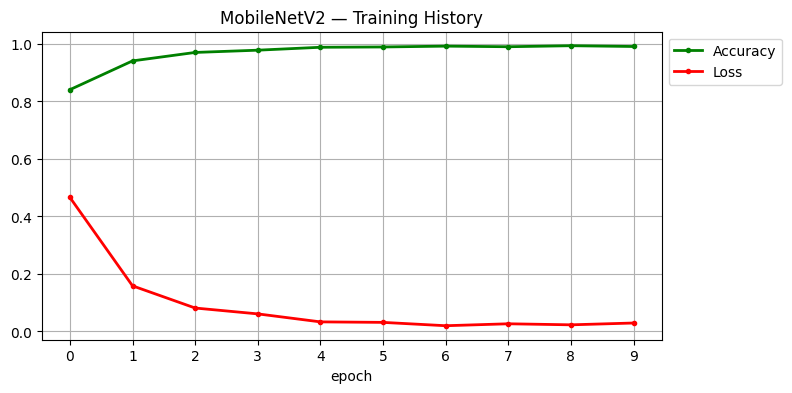

In [49]:
# ── Training History Plot (MobileNetV2) ──────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.grid(True)
plt.plot(history_mobilenet.history['sparse_categorical_accuracy'], '.g-', linewidth=2)
plt.plot(history_mobilenet.history['loss'], '.r-', linewidth=2)
plt.title('MobileNetV2 — Training History')
plt.xlabel('epoch')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1, 1))
plt.savefig('training_history_mobilenet.png', dpi=150, bbox_inches='tight')
plt.show()

In [50]:
# ── Evaluation (MobileNetV2) ──────────────────────────────────────────────────
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
from sklearn.preprocessing import label_binarize
import numpy as np

CLASS_NAMES = os.listdir(train_dir)

# 1. Prediction on test data
test_images = open_images_no_aug(test_paths)
test_labels_encoded = encode_label(test_labels)
test_predictions = model_mobilenet.predict(test_images)   # ← FIXED: model_mobilenet

# 2. Classification Report
print("=== MobileNetV2 — Classification Report ===")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1),
                             target_names=CLASS_NAMES))

41/41 [==============================] - 1s 11ms/step
=== MobileNetV2 — Classification Report ===
              precision    recall  f1-score   support

      glioma       0.99      0.84      0.91       300
  meningioma       0.84      0.93      0.88       306
     notumor       0.96      1.00      0.98       405
   pituitary       0.97      0.98      0.98       300

    accuracy                           0.94      1311
   macro avg       0.94      0.93      0.94      1311
weighted avg       0.94      0.94      0.94      1311



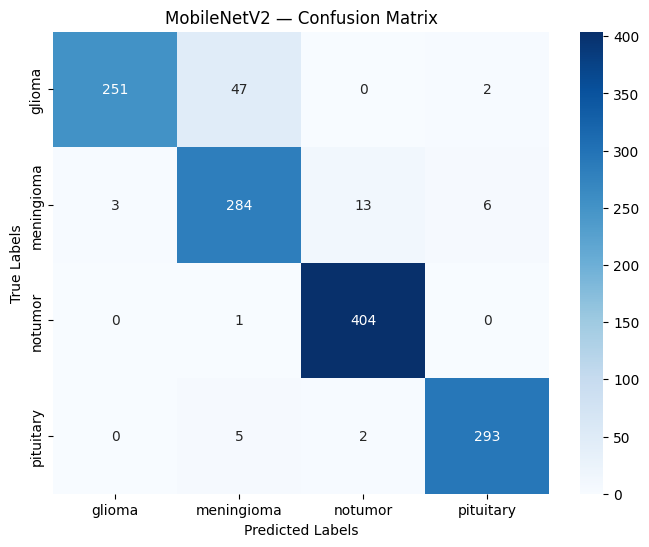

In [51]:
# 3. Confusion Matrix
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("MobileNetV2 — Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.savefig('confusion_matrix_mobilenet.png', dpi=150, bbox_inches='tight')
plt.show()

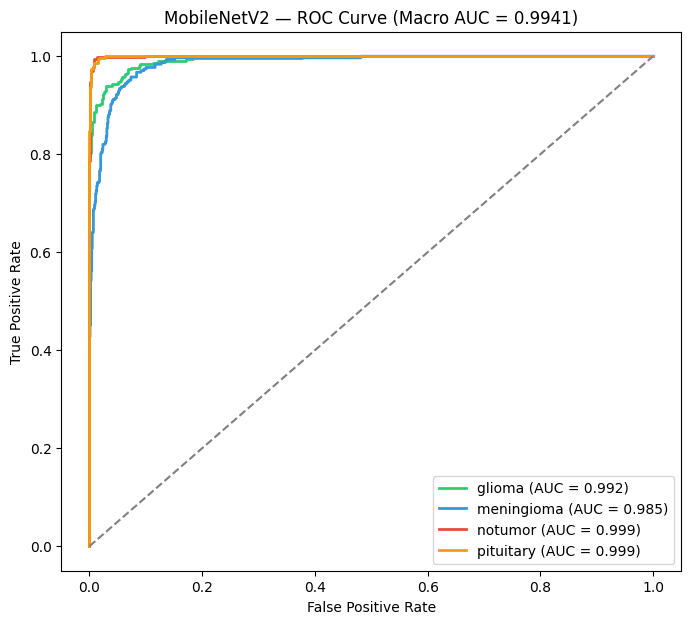


MobileNetV2 — Macro Average AUC: 0.9941


In [52]:
# 4. ROC Curve and AUC
n_classes = len(CLASS_NAMES)
test_labels_bin = label_binarize(test_labels_encoded, classes=np.arange(n_classes))

fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_predictions[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

macro_auc_mobilenet = np.mean(list(roc_auc.values()))

plt.figure(figsize=(8, 7))
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, linewidth=2,
             label=f'{CLASS_NAMES[i]} (AUC = {roc_auc[i]:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title(f"MobileNetV2 — ROC Curve (Macro AUC = {macro_auc_mobilenet:.4f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.savefig('roc_auc_mobilenet.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMobileNetV2 — Macro Average AUC: {macro_auc_mobilenet:.4f}")

1/1 [==============================] - 0s 29ms/step


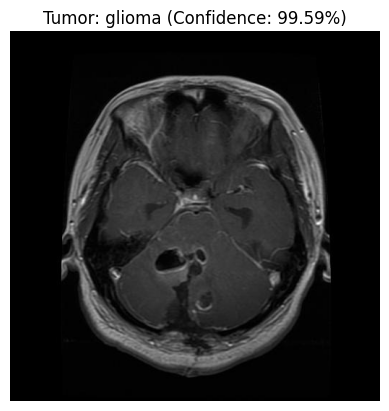

In [54]:
# Example usage
image_path = 'D:/Study/A_UniVR Class/ML & DP/DL/Brain Tumor Detection Project (Deep Learning)/MRI Images/Testing/glioma/Te-gl_0020.jpg'
detect_and_display(image_path, model)

**U-net**

In [55]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, concatenate
from tensorflow.keras.models import Model, Sequential

IMAGE_SIZE = 128

# --- Define U-Net Encoder Block ---
def unet_encoder(inputs):
    # Block 1
    c1 = Conv2D(16, (3, 3), activation='relu', padding='same')(inputs)
    p1 = MaxPooling2D((2, 2))(c1)
    # Block 2
    c2 = Conv2D(32, (3, 3), activation='relu', padding='same')(p1)
    p2 = MaxPooling2D((2, 2))(c2)
    # Block 3 (Bottleneck for Classification)
    c3 = Conv2D(64, (3, 3), activation='relu', padding='same')(p2)
    return c3

# Build Model
inputs = Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
base_model_output = unet_encoder(inputs)

model_unet = Sequential()
model_unet.add(Model(inputs=inputs, outputs=base_model_output))
model_unet.add(Flatten())
model_unet.add(Dropout(0.3))
model_unet.add(Dense(128, activation='relu'))
model_unet.add(Dropout(0.2))
model_unet.add(Dense(len(os.listdir(train_dir)), activation='softmax'))

model_unet.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

# Parameters
batch_size = 20
steps = int(len(train_paths) / batch_size)
val_steps = int(len(val_paths) / batch_size)    
epochs = 10

# Train the model (FIXED: history_unet, with validation)
history_unet = model_unet.fit(                                                 
    datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
    validation_data=val_datagen(val_paths, val_labels, batch_size=batch_size, image_size=IMAGE_SIZE),  
    validation_steps=val_steps,                                                  
    epochs=epochs,
    steps_per_epoch=steps
)

Epoch 1/10
242/242 [==============================] - 15s 56ms/step - loss: 0.7866 - sparse_categorical_accuracy: 0.6787 - val_loss: 0.5420 - val_sparse_categorical_accuracy: 0.7905
Epoch 2/10
242/242 [==============================] - 13s 54ms/step - loss: 0.4808 - sparse_categorical_accuracy: 0.8213 - val_loss: 0.4412 - val_sparse_categorical_accuracy: 0.8488
Epoch 3/10
242/242 [==============================] - 13s 55ms/step - loss: 0.3673 - sparse_categorical_accuracy: 0.8683 - val_loss: 0.3830 - val_sparse_categorical_accuracy: 0.8631
Epoch 4/10
242/242 [==============================] - 13s 54ms/step - loss: 0.3007 - sparse_categorical_accuracy: 0.8881 - val_loss: 0.3221 - val_sparse_categorical_accuracy: 0.8869
Epoch 5/10
242/242 [==============================] - 14s 56ms/step - loss: 0.2436 - sparse_categorical_accuracy: 0.9086 - val_loss: 0.3393 - val_sparse_categorical_accuracy: 0.8810
Epoch 6/10
242/242 [==============================] - 13s 55ms/step - loss: 0.2074 - spars

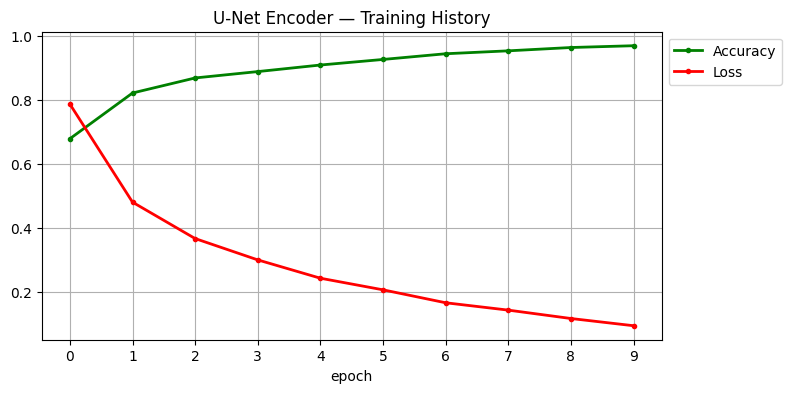

In [56]:
# ── Training History Plot (U-Net) ────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.grid(True)
plt.plot(history_unet.history['sparse_categorical_accuracy'], '.g-', linewidth=2)
plt.plot(history_unet.history['loss'], '.r-', linewidth=2)
plt.title('U-Net Encoder — Training History')
plt.xlabel('epoch')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1, 1))
plt.savefig('training_history_unet.png', dpi=150, bbox_inches='tight')
plt.show()

In [57]:
# ── Evaluation (U-Net) ────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
from sklearn.preprocessing import label_binarize
import numpy as np

CLASS_NAMES = os.listdir(train_dir)

# 1. Prediction on test data
test_images = open_images_no_aug(test_paths)
test_labels_encoded = encode_label(test_labels)
test_predictions = model_unet.predict(test_images)   

# 2. Classification Report
print("=== U-Net Encoder — Classification Report ===")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1),
                             target_names=CLASS_NAMES))

41/41 [==============================] - 0s 6ms/step
=== U-Net Encoder — Classification Report ===
              precision    recall  f1-score   support

      glioma       0.98      0.75      0.85       300
  meningioma       0.79      0.86      0.83       306
     notumor       0.94      1.00      0.97       405
   pituitary       0.94      1.00      0.97       300

    accuracy                           0.91      1311
   macro avg       0.91      0.90      0.90      1311
weighted avg       0.91      0.91      0.91      1311



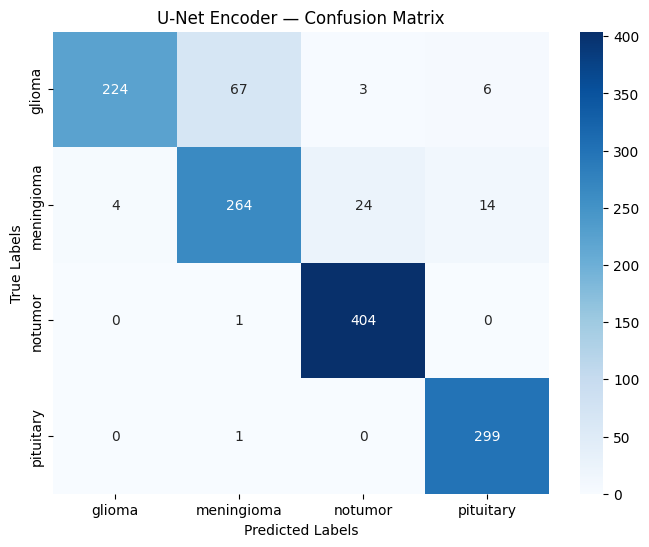

In [58]:
# 3. Confusion Matrix
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("U-Net Encoder — Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.savefig('confusion_matrix_unet.png', dpi=150, bbox_inches='tight')
plt.show()

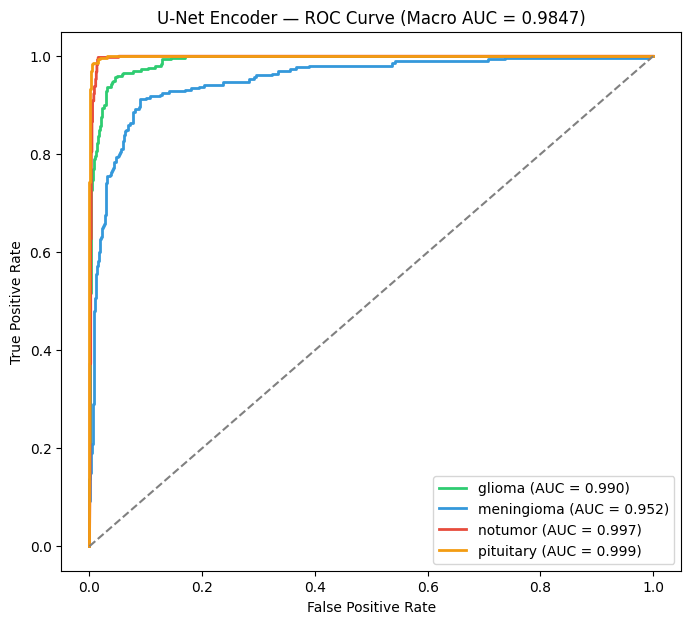


U-Net Encoder — Macro Average AUC: 0.9847


In [59]:
# 4. ROC Curve and AUC
n_classes = len(CLASS_NAMES)
test_labels_bin = label_binarize(test_labels_encoded, classes=np.arange(n_classes))

fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_predictions[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

macro_auc_unet = np.mean(list(roc_auc.values()))

plt.figure(figsize=(8, 7))
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, linewidth=2,
             label=f'{CLASS_NAMES[i]} (AUC = {roc_auc[i]:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title(f"U-Net Encoder — ROC Curve (Macro AUC = {macro_auc_unet:.4f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.savefig('roc_auc_unet.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nU-Net Encoder — Macro Average AUC: {macro_auc_unet:.4f}")


In [62]:
# ── Qualitative Example Function (Reusable for all models) ──────────────────
from tensorflow.keras.preprocessing.image import load_img, img_to_array

CLASS_LABELS = os.listdir(train_dir)   # FIXED: dynamic, no hardcoding

def detect_and_display(img_path, model, image_size=128):
    """
    Detects tumor type and displays the result.
    Works with ANY trained model — pass model_unet, model_resnet50, etc.
    """
    try:
        img = load_img(img_path, target_size=(image_size, image_size))
        img_array = img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions, axis=1)[0]
        confidence_score = np.max(predictions, axis=1)[0]

        predicted_label = CLASS_LABELS[predicted_class_index]
        result = "No Tumor" if predicted_label == 'notumor' else f"Tumor: {predicted_label}"

        plt.imshow(load_img(img_path))
        plt.axis('off')
        plt.title(f"{result} (Confidence: {confidence_score * 100:.2f}%)")
        plt.show()

    except Exception as e:
        print("Error processing the image:", str(e))




1/1 [==============================] - 0s 26ms/step


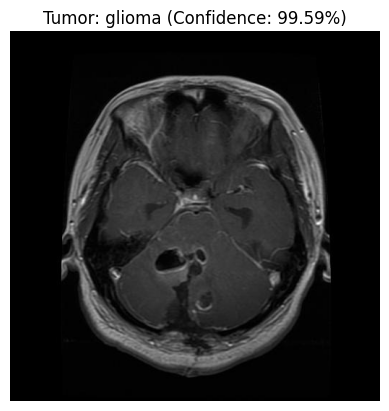

In [63]:
# Example usage
image_path = 'D:/Study/A_UniVR Class/ML & DP/DL/Brain Tumor Detection Project (Deep Learning)/MRI Images/Testing/glioma/Te-gl_0020.jpg'
detect_and_display(image_path, model)

**Model: CNN + LSTM**

In [64]:
IMAGE_SIZE = 128
model_cnn_lstm = Sequential()
model_cnn_lstm.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))
model_cnn_lstm.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model_cnn_lstm.add(MaxPooling2D((2,2)))
model_cnn_lstm.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model_cnn_lstm.add(MaxPooling2D((2,2)))
model_cnn_lstm.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model_cnn_lstm.add(MaxPooling2D((2,2)))
model_cnn_lstm.add(Flatten())
model_cnn_lstm.add(Reshape((64, -1)))
model_cnn_lstm.add(LSTM(64))
model_cnn_lstm.add(Dropout(0.3))
model_cnn_lstm.add(Dense(128, activation='relu'))
model_cnn_lstm.add(Dropout(0.2))
model_cnn_lstm.add(Dense(len(os.listdir(train_dir)), activation='softmax'))

model_cnn_lstm.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

# Parameters
batch_size = 20
steps = int(len(train_paths) / batch_size)
val_steps = int(len(val_paths) / batch_size)    # ← যোগ করো
epochs = 10

# Train the model (with validation)
history_cnn_lstm = model_cnn_lstm.fit(
    datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
    validation_data=val_datagen(val_paths, val_labels, batch_size=batch_size, image_size=IMAGE_SIZE),  # ← যোগ করো
    validation_steps=val_steps,                  # ← যোগ করো
    epochs=epochs,
    steps_per_epoch=steps
)

Epoch 1/10
242/242 [==============================] - 29s 63ms/step - loss: 1.2166 - sparse_categorical_accuracy: 0.3924 - val_loss: 1.0524 - val_sparse_categorical_accuracy: 0.5857
Epoch 2/10
242/242 [==============================] - 14s 56ms/step - loss: 0.9738 - sparse_categorical_accuracy: 0.5741 - val_loss: 0.8694 - val_sparse_categorical_accuracy: 0.6226
Epoch 3/10
242/242 [==============================] - 13s 54ms/step - loss: 0.8315 - sparse_categorical_accuracy: 0.6554 - val_loss: 0.7468 - val_sparse_categorical_accuracy: 0.7036
Epoch 4/10
242/242 [==============================] - 13s 55ms/step - loss: 0.7482 - sparse_categorical_accuracy: 0.6945 - val_loss: 0.6217 - val_sparse_categorical_accuracy: 0.7726
Epoch 5/10
242/242 [==============================] - 13s 55ms/step - loss: 0.7210 - sparse_categorical_accuracy: 0.7088 - val_loss: 0.5990 - val_sparse_categorical_accuracy: 0.7607
Epoch 6/10
242/242 [==============================] - 13s 55ms/step - loss: 0.6598 - spars

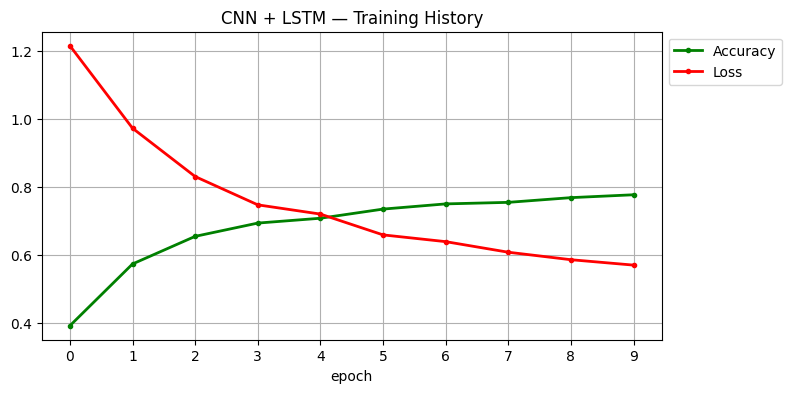

In [65]:
# ── Training History Plot (CNN+LSTM) ─────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.grid(True)
plt.plot(history_cnn_lstm.history['sparse_categorical_accuracy'], '.g-', linewidth=2)
plt.plot(history_cnn_lstm.history['loss'], '.r-', linewidth=2)
plt.title('CNN + LSTM — Training History')
plt.xlabel('epoch')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1, 1))
plt.savefig('training_history_cnn_lstm.png', dpi=150, bbox_inches='tight')
plt.show()

In [66]:
# ── Evaluation (CNN+LSTM) ─────────────────────────────────────────────────────
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
from sklearn.preprocessing import label_binarize
import numpy as np

CLASS_NAMES = os.listdir(train_dir)

# 1. Prediction on test data
test_images = open_images_no_aug(test_paths)         # ← FIXED: no augmentation
test_labels_encoded = encode_label(test_labels)
test_predictions = model_cnn_lstm.predict(test_images)    # ← FIXED: model_cnn_lstm

# 2. Classification Report
print("=== CNN + LSTM — Classification Report ===")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1),
                             target_names=CLASS_NAMES))

41/41 [==============================] - 1s 14ms/step
=== CNN + LSTM — Classification Report ===
              precision    recall  f1-score   support

      glioma       0.95      0.29      0.44       300
  meningioma       0.47      0.55      0.51       306
     notumor       0.82      0.94      0.87       405
   pituitary       0.74      0.97      0.84       300

    accuracy                           0.71      1311
   macro avg       0.74      0.69      0.67      1311
weighted avg       0.75      0.71      0.68      1311



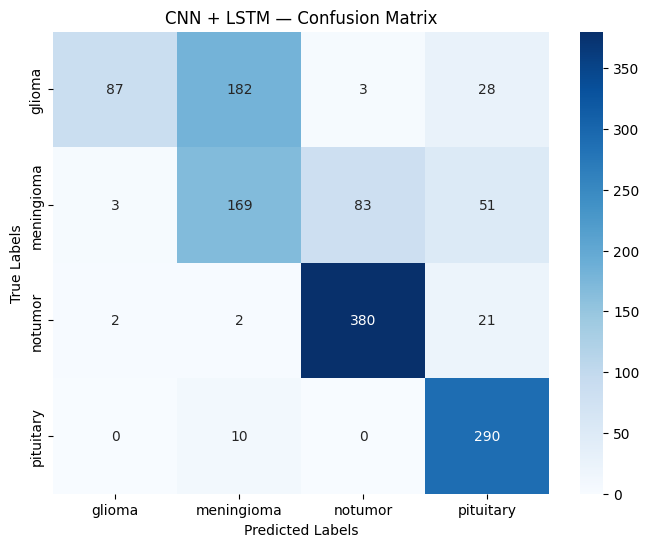

In [67]:
# 3. Confusion Matrix
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("CNN + LSTM — Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.savefig('confusion_matrix_cnn_lstm.png', dpi=150, bbox_inches='tight')
plt.show()

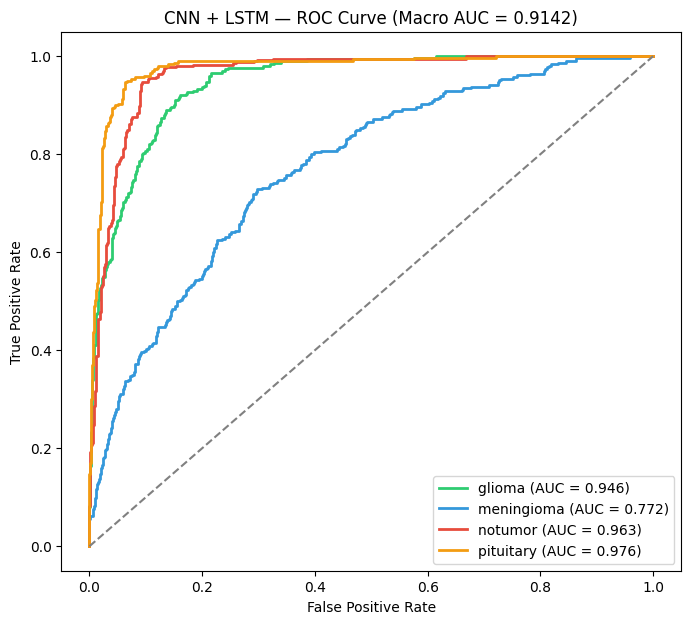


CNN + LSTM — Macro Average AUC: 0.9142


In [68]:
# 4. ROC Curve and AUC
n_classes = len(CLASS_NAMES)
test_labels_bin = label_binarize(test_labels_encoded, classes=np.arange(n_classes))

fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_predictions[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

macro_auc_cnn_lstm = np.mean(list(roc_auc.values()))

plt.figure(figsize=(8, 7))
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, linewidth=2,
             label=f'{CLASS_NAMES[i]} (AUC = {roc_auc[i]:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title(f"CNN + LSTM — ROC Curve (Macro AUC = {macro_auc_cnn_lstm:.4f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.savefig('roc_auc_cnn_lstm.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nCNN + LSTM — Macro Average AUC: {macro_auc_cnn_lstm:.4f}")

1/1 [==============================] - 0s 25ms/step


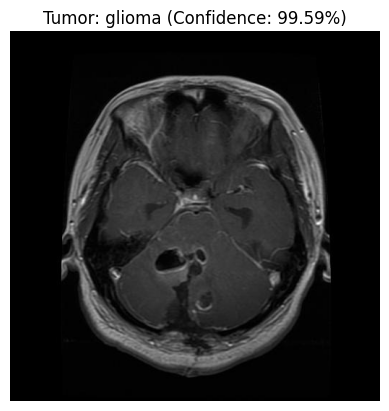

In [71]:
# Example usage
image_path = 'D:/Study/A_UniVR Class/ML & DP/DL/Brain Tumor Detection Project (Deep Learning)/MRI Images/Testing/glioma/Te-gl_0020.jpg'
detect_and_display(image_path, model)

41/41 [==============================] - 0s 9ms/step
=== Final Comparison — All 5 Models ===
        Model  Accuracy  Macro F1  Weighted F1
        VGG16    0.9672    0.9653       0.9670
  MobileNetV2    0.9397    0.9363       0.9396
U-Net Encoder    0.9085    0.9018       0.9067
     ResNet50    0.7307    0.6726       0.6917
   CNN + LSTM    0.7063    0.6656       0.6814

Best Model: VGG16 (Accuracy = 0.9672)


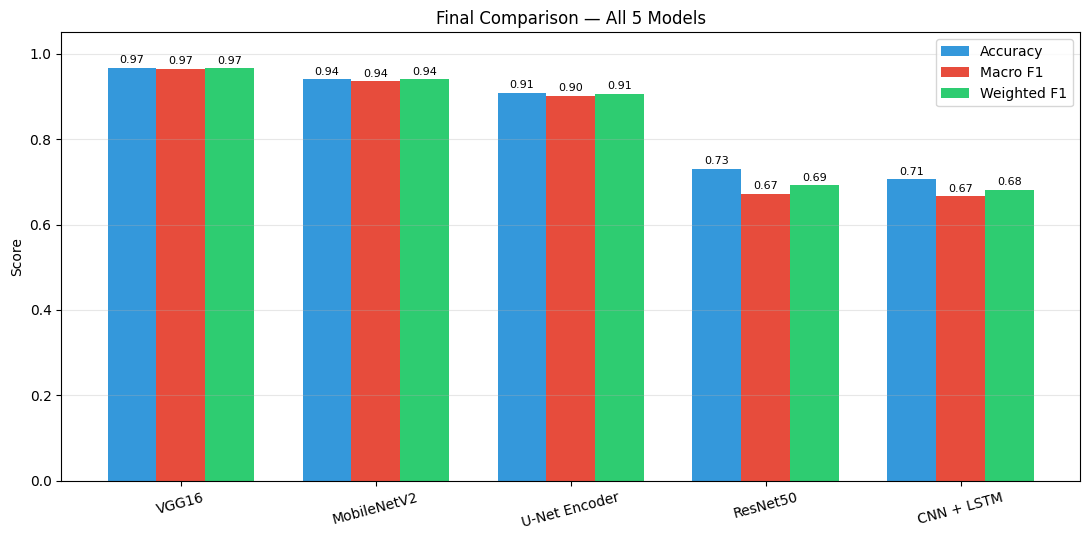

In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
 
CLASS_NAMES = os.listdir(train_dir)
test_images_eval = open_images_no_aug(test_paths)
test_labels_encoded_eval = encode_label(test_labels)
 
all_models = {
    'VGG16': model,
    'ResNet50': model_resnet50,
    'MobileNetV2': model_mobilenet,
    'U-Net Encoder': model_unet,
    'CNN + LSTM': model_cnn_lstm,
}
 
comparison_results = []
for name, mdl in all_models.items():
    preds = mdl.predict(test_images_eval)
    pred_classes = np.argmax(preds, axis=1)
    acc = np.mean(pred_classes == test_labels_encoded_eval)
    macro_f1 = f1_score(test_labels_encoded_eval, pred_classes, average='macro')
    weighted_f1 = f1_score(test_labels_encoded_eval, pred_classes, average='weighted')
    comparison_results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Macro F1': round(macro_f1, 4),
        'Weighted F1': round(weighted_f1, 4),
    })
 
comparison_df = pd.DataFrame(comparison_results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
print("=== Final Comparison — All 5 Models ===")
print(comparison_df.to_string(index=False))
print(f"\nBest Model: {comparison_df.iloc[0]['Model']} (Accuracy = {comparison_df.iloc[0]['Accuracy']})")
 
# Bar chart
x = np.arange(len(comparison_df))
width = 0.25
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.bar(x - width, comparison_df['Accuracy'], width, label='Accuracy', color='#3498db')
ax.bar(x, comparison_df['Macro F1'], width, label='Macro F1', color='#e74c3c')
ax.bar(x + width, comparison_df['Weighted F1'], width, label='Weighted F1', color='#2ecc71')
 
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'], rotation=15)
ax.set_ylabel('Score')
ax.set_ylim([0, 1.05])
ax.set_title('Final Comparison — All 5 Models')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
 
for i, row in comparison_df.iterrows():
    ax.text(i - width, row['Accuracy'] + 0.01, f"{row['Accuracy']:.2f}", ha='center', fontsize=8)
    ax.text(i, row['Macro F1'] + 0.01, f"{row['Macro F1']:.2f}", ha='center', fontsize=8)
    ax.text(i + width, row['Weighted F1'] + 0.01, f"{row['Weighted F1']:.2f}", ha='center', fontsize=8)
 
plt.tight_layout()
plt.savefig('final_comparison_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

 ABLATION STUDY — VGG16 Hyperparameter Variants

In [74]:
# ── Variant A: Higher Learning Rate (0.001 instead of 0.0001) ───────────────
base_model_a = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')
for layer in base_model_a.layers:
    layer.trainable = False
base_model_a.layers[-2].trainable = True
base_model_a.layers[-3].trainable = True
base_model_a.layers[-4].trainable = True
 
model_vgg16_variantA = Sequential()
model_vgg16_variantA.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))
model_vgg16_variantA.add(base_model_a)
model_vgg16_variantA.add(Flatten())
model_vgg16_variantA.add(Dropout(0.3))
model_vgg16_variantA.add(Dense(128, activation='relu'))
model_vgg16_variantA.add(Dropout(0.2))
model_vgg16_variantA.add(Dense(len(os.listdir(train_dir)), activation='softmax'))
 
model_vgg16_variantA.compile(optimizer=Adam(learning_rate=0.001),   # CHANGED: 0.0001 -> 0.001
                              loss='sparse_categorical_crossentropy',
                              metrics=['sparse_categorical_accuracy'])
 
val_steps = int(len(val_paths) / batch_size)
 
history_vgg16_variantA = model_vgg16_variantA.fit(
    datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
    validation_data=val_datagen(val_paths, val_labels, batch_size=batch_size, image_size=IMAGE_SIZE),
    validation_steps=val_steps,
    epochs=epochs,
    steps_per_epoch=steps)

Epoch 1/10
242/242 [==============================] - 63s 256ms/step - loss: 1.3961 - sparse_categorical_accuracy: 0.2762 - val_loss: 1.3835 - val_sparse_categorical_accuracy: 0.2786
Epoch 2/10
242/242 [==============================] - 13s 54ms/step - loss: 1.3838 - sparse_categorical_accuracy: 0.2794 - val_loss: 1.3834 - val_sparse_categorical_accuracy: 0.2786
Epoch 3/10
242/242 [==============================] - 13s 54ms/step - loss: 1.3837 - sparse_categorical_accuracy: 0.2802 - val_loss: 1.3834 - val_sparse_categorical_accuracy: 0.2786
Epoch 4/10
242/242 [==============================] - 14s 56ms/step - loss: 1.3838 - sparse_categorical_accuracy: 0.2794 - val_loss: 1.3834 - val_sparse_categorical_accuracy: 0.2786
Epoch 5/10
242/242 [==============================] - 15s 60ms/step - loss: 1.3836 - sparse_categorical_accuracy: 0.2798 - val_loss: 1.3835 - val_sparse_categorical_accuracy: 0.2786
Epoch 6/10
242/242 [==============================] - 13s 54ms/step - loss: 1.3836 - spar

In [75]:
 
# ── Variant B: Heavier Dropout (0.5 instead of 0.3) ──────────────────────────
base_model_b = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')
for layer in base_model_b.layers:
    layer.trainable = False
base_model_b.layers[-2].trainable = True
base_model_b.layers[-3].trainable = True
base_model_b.layers[-4].trainable = True
 
model_vgg16_variantB = Sequential()
model_vgg16_variantB.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))
model_vgg16_variantB.add(base_model_b)
model_vgg16_variantB.add(Flatten())
model_vgg16_variantB.add(Dropout(0.5))    
model_vgg16_variantB.add(Dense(128, activation='relu'))
model_vgg16_variantB.add(Dropout(0.2))
model_vgg16_variantB.add(Dense(len(os.listdir(train_dir)), activation='softmax'))
 
model_vgg16_variantB.compile(optimizer=Adam(learning_rate=0.0001),
                              loss='sparse_categorical_crossentropy',
                              metrics=['sparse_categorical_accuracy'])
 
history_vgg16_variantB = model_vgg16_variantB.fit(
    datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
    validation_data=val_datagen(val_paths, val_labels, batch_size=batch_size, image_size=IMAGE_SIZE),
    validation_steps=val_steps,
    epochs=epochs,
    steps_per_epoch=steps
)
 

Epoch 1/10
242/242 [==============================] - 14s 53ms/step - loss: 0.5333 - sparse_categorical_accuracy: 0.7950 - val_loss: 0.2811 - val_sparse_categorical_accuracy: 0.8917
Epoch 2/10
242/242 [==============================] - 15s 60ms/step - loss: 0.2682 - sparse_categorical_accuracy: 0.8987 - val_loss: 0.2053 - val_sparse_categorical_accuracy: 0.9250
Epoch 3/10
242/242 [==============================] - 14s 56ms/step - loss: 0.1800 - sparse_categorical_accuracy: 0.9326 - val_loss: 0.2396 - val_sparse_categorical_accuracy: 0.9250
Epoch 4/10
242/242 [==============================] - 13s 55ms/step - loss: 0.1536 - sparse_categorical_accuracy: 0.9402 - val_loss: 0.1772 - val_sparse_categorical_accuracy: 0.9452
Epoch 5/10
242/242 [==============================] - 14s 56ms/step - loss: 0.1163 - sparse_categorical_accuracy: 0.9551 - val_loss: 0.1577 - val_sparse_categorical_accuracy: 0.9452
Epoch 6/10
242/242 [==============================] - 15s 60ms/step - loss: 0.0898 - spars

In [79]:
# ── Variant C: Deeper Fine-tuning (last 6 layers instead of last 3) ──────────
base_model_c = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

for layer in base_model_c.layers:
    layer.trainable = False

# Unfreeze last 6 layers instead of last 3
for layer in base_model_c.layers[-6:]:
    layer.trainable = True

model_vgg16_variantC = Sequential()
model_vgg16_variantC.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))
model_vgg16_variantC.add(base_model_c)
model_vgg16_variantC.add(Flatten())
model_vgg16_variantC.add(Dropout(0.3))
model_vgg16_variantC.add(Dense(128, activation='relu'))
model_vgg16_variantC.add(Dropout(0.2))
model_vgg16_variantC.add(Dense(len(os.listdir(train_dir)), activation='softmax'))

model_vgg16_variantC.compile(optimizer=Adam(learning_rate=0.0001),
                              loss='sparse_categorical_crossentropy',
                              metrics=['sparse_categorical_accuracy'])

history_vgg16_variantC = model_vgg16_variantC.fit(
    datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
    validation_data=val_datagen(val_paths, val_labels, batch_size=batch_size, image_size=IMAGE_SIZE),
    validation_steps=val_steps,
    epochs=epochs,
    steps_per_epoch=steps
)

Epoch 1/10
242/242 [==============================] - 13s 52ms/step - loss: 0.5056 - sparse_categorical_accuracy: 0.8004 - val_loss: 0.2770 - val_sparse_categorical_accuracy: 0.8917
Epoch 2/10
242/242 [==============================] - 12s 50ms/step - loss: 0.2148 - sparse_categorical_accuracy: 0.9164 - val_loss: 0.1789 - val_sparse_categorical_accuracy: 0.9381
Epoch 3/10
242/242 [==============================] - 12s 49ms/step - loss: 0.1453 - sparse_categorical_accuracy: 0.9433 - val_loss: 0.1816 - val_sparse_categorical_accuracy: 0.9298
Epoch 4/10
242/242 [==============================] - 12s 51ms/step - loss: 0.1089 - sparse_categorical_accuracy: 0.9615 - val_loss: 0.2002 - val_sparse_categorical_accuracy: 0.9333
Epoch 5/10
242/242 [==============================] - 13s 53ms/step - loss: 0.0803 - sparse_categorical_accuracy: 0.9729 - val_loss: 0.1606 - val_sparse_categorical_accuracy: 0.9595
Epoch 6/10
242/242 [==============================] - 12s 51ms/step - loss: 0.0668 - spars

41/41 [==============================] - 2s 33ms/step
=== VGG16 Ablation Study — Results ===
                     Variant  Test Accuracy  Macro F1
        Baseline (LR=0.0001)         0.9672    0.9653
        Variant A (LR=0.001)         0.3089    0.1180
     Variant B (Dropout=0.5)         0.9619    0.9596
Variant C (Fine-tune last 6)         0.9314    0.9277


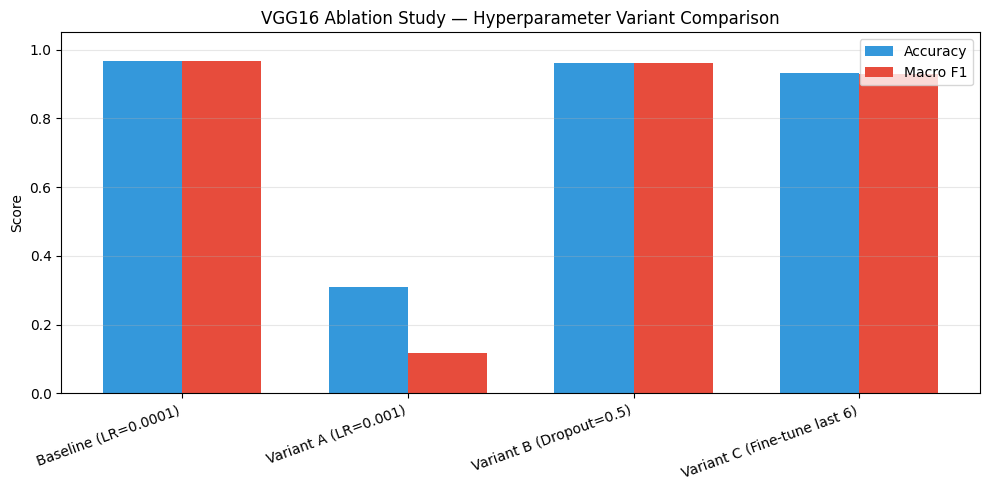

In [80]:

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, f1_score
from sklearn.preprocessing import label_binarize
import seaborn as sns
import numpy as np
import pandas as pd
 
CLASS_NAMES = os.listdir(train_dir)
test_images = open_images_no_aug(test_paths)
test_labels_encoded = encode_label(test_labels)
 
ablation_results = []
 
variants = {
    'Baseline (LR=0.0001)': model,                   # the original VGG16 model trained earlier
    'Variant A (LR=0.001)': model_vgg16_variantA,
    'Variant B (Dropout=0.5)': model_vgg16_variantB,
    'Variant C (Fine-tune last 6)': model_vgg16_variantC,
}
 
for name, mdl in variants.items():
    preds = mdl.predict(test_images)
    pred_classes = np.argmax(preds, axis=1)
    acc = np.mean(pred_classes == test_labels_encoded)
    macro_f1 = f1_score(test_labels_encoded, pred_classes, average='macro')
    ablation_results.append({'Variant': name, 'Test Accuracy': round(acc, 4), 'Macro F1': round(macro_f1, 4)})
 
ablation_df = pd.DataFrame(ablation_results)
print("=== VGG16 Ablation Study — Results ===")
print(ablation_df.to_string(index=False))
 
# Bar chart comparison
plt.figure(figsize=(10, 5))
x = np.arange(len(ablation_df))
width = 0.35
plt.bar(x - width/2, ablation_df['Test Accuracy'], width, label='Accuracy', color='#3498db')
plt.bar(x + width/2, ablation_df['Macro F1'], width, label='Macro F1', color='#e74c3c')
plt.xticks(x, ablation_df['Variant'], rotation=20, ha='right')
plt.ylabel('Score')
plt.title('VGG16 Ablation Study — Hyperparameter Variant Comparison')
plt.ylim([0, 1.05])
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('ablation_study_vgg16.png', dpi=150, bbox_inches='tight')
plt.show()

In [81]:
pip install opencv-python

  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl.metadata (60 kB)
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
    --------------------------------------- 0.5/40.2 MB 3.4 MB/s eta 0:00:12
   - -------------------------------------- 1.3/40.2 MB 3.9 MB/s eta 0:00:10
   -- ------------------------------------- 2.4/40.2 MB 4.1 MB/s eta 0:00:10
   --- ------------------------------------ 3.4/40.2 MB 4.5 MB/s eta 0:00:09
   ---- ----------------------------------- 5.0/40.2 MB 5.0 MB/s eta 0:00:08
   ----- ---------------------------------- 6.0/40.2 MB 5.1 MB/s eta 0:00:07
   ------- -------------------------------- 7.3/40.2 MB 5.3 MB/s eta 0:00:07
   -------- ------------------------------- 8.7/40.2 MB 5.4 MB/s eta 0:00:06
   ---------- ----------------------------- 10.7/40.2 MB 6.0 MB/s eta 0:00:05
   ------------ --------------------------- 12.3/40.2 MB 6.2 MB/s eta 0:00:05
   --------------- ------------------------ 15.2/40.2 MB 6.8 MB/s eta 0:00:04
   -------

  You can safely remove it manually.


# EXPLAINABILITY — Grad-CAM Visualization (VGG16)

In [84]:
from scipy.ndimage import zoom
print("scipy works!")

scipy works!


In [120]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import zoom

 


Intermediate layer output shape: (1, 16, 16, 512)

--- Grad-CAM for class: glioma ---


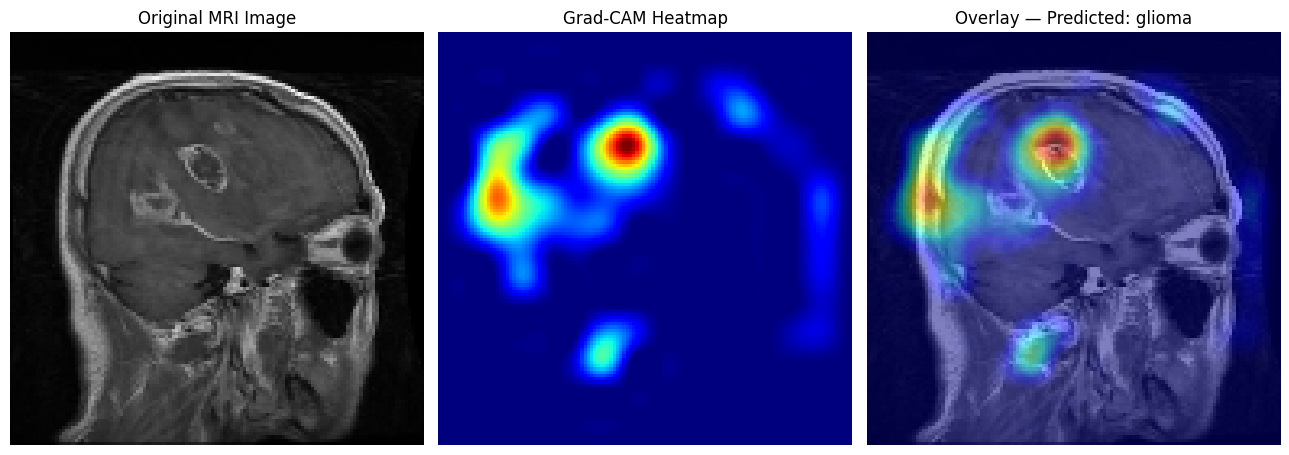


--- Grad-CAM for class: meningioma ---


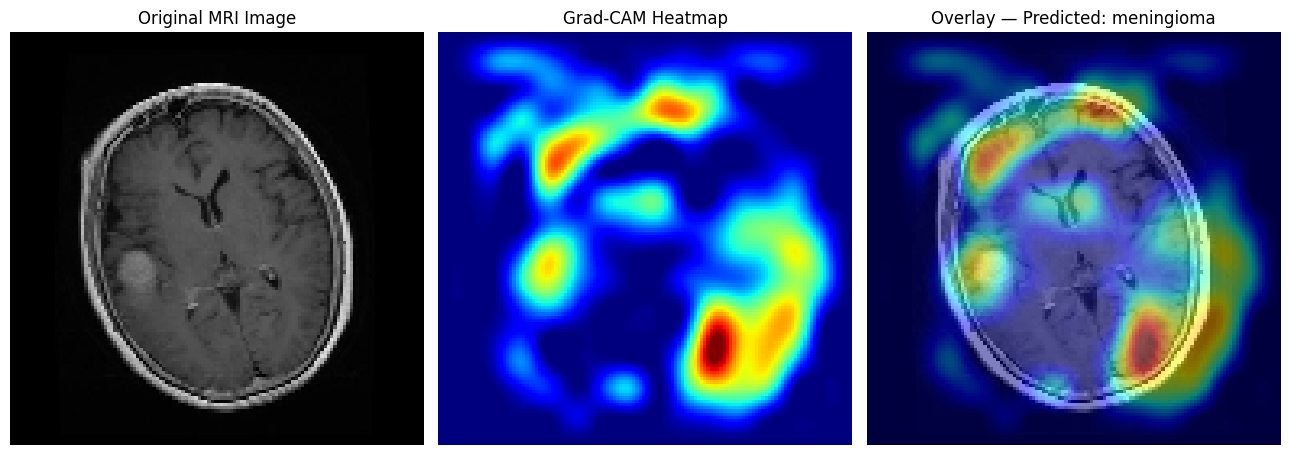


--- Grad-CAM for class: notumor ---


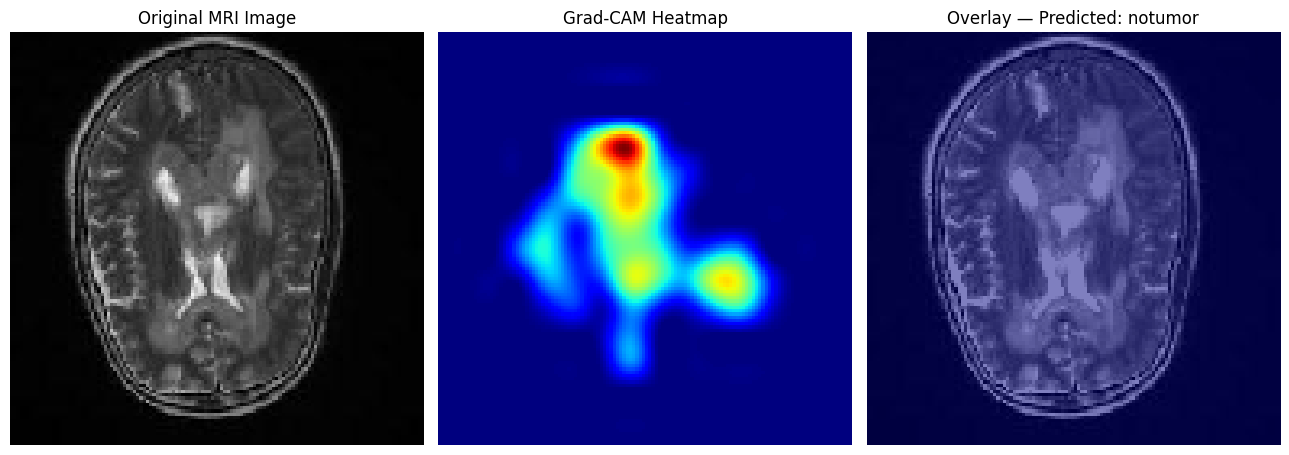


--- Grad-CAM for class: pituitary ---


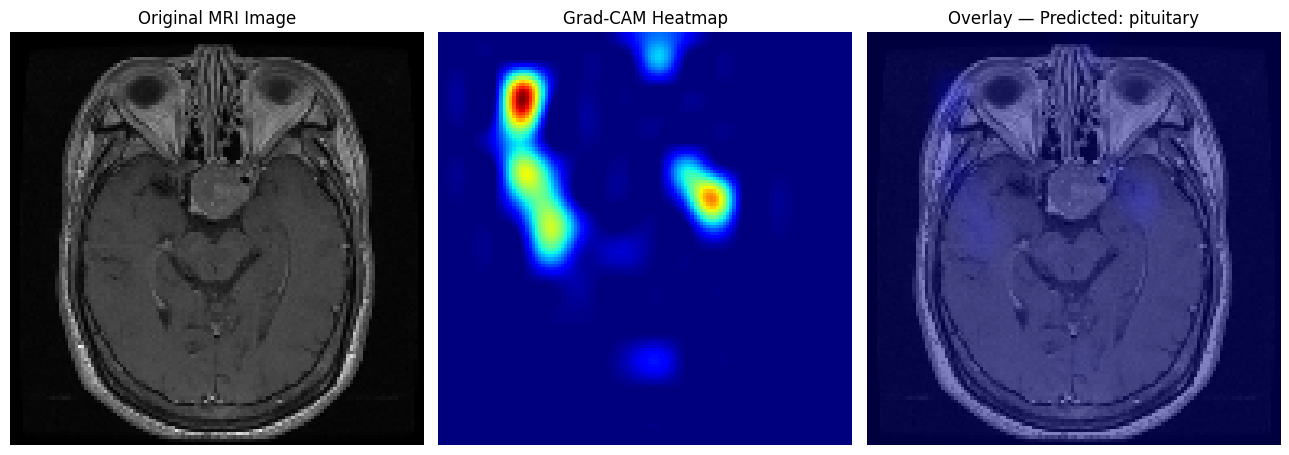

In [124]:
 
def build_gradcam_models(model, conv_layer_name='block4_conv3'):
    """
    Builds two sub-models from the trained Sequential model:
    1. `vgg_to_conv`: VGG16 input -> chosen intermediate conv layer output
    2. `conv_to_output`: chosen conv layer output -> final prediction
       (this rebuilds the REMAINING VGG16 layers + the classification head
        as a single functional model, avoiding manual layer replay)
    """
    vgg16_backbone = model.layers[0]
 
    # Sub-model 1: input -> intermediate conv layer
    vgg_to_conv = tf.keras.models.Model(
        inputs=vgg16_backbone.input,
        outputs=vgg16_backbone.get_layer(conv_layer_name).output
    )
 
    # Sub-model 2: intermediate conv layer -> VGG16 final output
    # Find the index of the chosen layer, then rebuild from there
    layer_names = [l.name for l in vgg16_backbone.layers]
    start_idx = layer_names.index(conv_layer_name) + 1
 
    conv_input = tf.keras.Input(shape=vgg_to_conv.output.shape[1:])
    x = conv_input
    for layer in vgg16_backbone.layers[start_idx:]:
        x = layer(x)
    # Continue through the classification head (Flatten, Dropout, Dense, ...)
    for layer in model.layers[1:]:
        x = layer(x)
    conv_to_output = tf.keras.models.Model(inputs=conv_input, outputs=x)
 
    return vgg_to_conv, conv_to_output
 
 
def display_gradcam(img_path, vgg_to_conv, conv_to_output, class_names, image_size=128, alpha=0.5):
    img = load_img(img_path, target_size=(image_size, image_size))
    img_array = img_to_array(img) / 255.0
    img_array_batch = np.expand_dims(img_array, axis=0)

    heatmap, pred_index = get_gradcam_heatmap(vgg_to_conv, conv_to_output, img_array_batch)

    zoom_factor = image_size / heatmap.shape[0]
    heatmap_resized = zoom(heatmap, zoom_factor)
    heatmap_resized = np.clip(heatmap_resized, 0, 1)

    cmap = plt.cm.jet
    heatmap_colored = cmap(heatmap_resized)[:, :, :3]

    # FIX: Adaptive brightness — stretch contrast based on this image's own range
    img_min, img_max = img_array.min(), img_array.max()
    if img_max > img_min:
        img_for_overlay = (img_array - img_min) / (img_max - img_min)
    else:
        img_for_overlay = img_array
    img_for_overlay = np.clip(img_for_overlay * 1.8, 0, 1)   # stronger boost

    overlay = heatmap_colored * alpha + img_for_overlay * (1 - alpha)

    fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
    axes[0].imshow(img_array)
    axes[0].set_title('Original MRI Image')
    axes[0].axis('off')

    axes[1].imshow(heatmap_resized, cmap='jet')
    axes[1].set_title('Grad-CAM Heatmap')
    axes[1].axis('off')

    axes[2].imshow(overlay)
    axes[2].set_title(f'Overlay — Predicted: {class_names[pred_index]}')
    axes[2].axis('off')

    plt.tight_layout()
    plt.savefig(f'gradcam_{class_names[pred_index]}.png', dpi=150, bbox_inches='tight')
    plt.show()
 
 
# ── Build the sub-models ONCE (reused for all images) ────────────────────────
vgg_to_conv, conv_to_output = build_gradcam_models(model, conv_layer_name='block4_conv3')
 
# Sanity check — print the spatial resolution we'll get
test_out = vgg_to_conv(np.zeros((1, IMAGE_SIZE, IMAGE_SIZE, 3)))
print("Intermediate layer output shape:", test_out.shape)   # should be (1, 16, 16, 512) for block4_conv3
 
 
# ── Generate Grad-CAM for one example image per class ────────────────────────
CLASS_NAMES = os.listdir(train_dir)
for cls in CLASS_NAMES:
    example_path = [p for p, l in zip(test_paths, test_labels) if l == cls][0]
    print(f"\n--- Grad-CAM for class: {cls} ---")
    display_gradcam(example_path, vgg_to_conv, conv_to_output, CLASS_NAMES, image_size=IMAGE_SIZE)
 

References

The architectures implemented in this project are based on the
following original works:


1. Simonyan, K., & Zisserman, A. (2015). Very Deep Convolutional
Networks for Large-Scale Image Recognition. International
Conference on Learning Representations (ICLR).
https://arxiv.org/abs/1409.1556
— Reference for the VGG16 architecture.
2. He, K., Zhang, X., Ren, S., & Sun, J. (2016). Deep Residual
Learning for Image Recognition. IEEE Conference on Computer Vision
and Pattern Recognition (CVPR), pp. 770–778.
https://arxiv.org/abs/1512.03385
— Reference for the ResNet50 architecture and its residual
(skip) connections.
3. Sandler, M., Howard, A., Zhu, M., Zhmoginov, A., & Chen, L.-C.
(2018). MobileNetV2: Inverted Residuals and Linear Bottlenecks.
IEEE Conference on Computer Vision and Pattern Recognition (CVPR),
pp. 4510–4520.
https://arxiv.org/abs/1801.04381
— Reference for the MobileNetV2 architecture.
4. Ronneberger, O., Fischer, P., & Brox, T. (2015). U-Net:
Convolutional Networks for Biomedical Image Segmentation.
Medical Image Computing and Computer-Assisted Intervention
(MICCAI), LNCS 9351, pp. 234–241.
https://arxiv.org/abs/1505.04597
— Reference for the U-Net encoder architecture, adapted here
for classification rather than segmentation.
5. Hochreiter, S., & Schmidhuber, J. (1997). Long Short-Term Memory.
Neural Computation, 9(8), 1735–1780.
— Reference for the LSTM layer used in the CNN+LSTM hybrid model.
6. Deng, J., Dong, W., Socher, R., Li, L.-J., Li, K., & Fei-Fei, L.
(2009). ImageNet: A Large-Scale Hierarchical Image Database.
IEEE Conference on Computer Vision and Pattern Recognition (CVPR).
— Source of the pretrained weights used for transfer learning in
VGG16, ResNet50, and MobileNetV2.
7. Cheng, J. (2017). Brain Tumor Dataset. Figshare.
https://doi.org/10.6084/m9.figshare.1512427
— Original source of the brain MRI dataset used in this study.